# Visualizing data in Python


# Scatter plot

A scatter plot is a type of graph that displays values for two numerical variables as a collection of points. 

Each point's position on the horizontal (x-axis) and vertical (y-axis) axis indicates the values for an individual data point.

Scatter plots are useful to illustrate relationships (correlation).

In the example below:

- Each dot represents one student.
- The horizontal position of the dot shows how many hours that student studied.
- The vertical position of the dot shows the test score that student received.

You can visually look for a trend. In this example, you'd likely see a positive correlation: as the "Hours Studied" (on the x-axis) increases, the "Test Score (%)" (on the y-axis) also tends to increase.

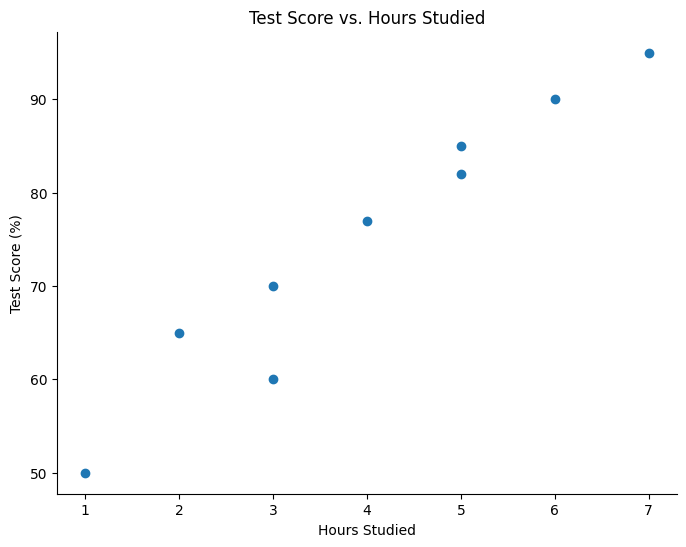

<Figure size 640x480 with 0 Axes>

In [2]:
import matplotlib.pyplot as plt

# --- 1. Prepare Basic Data ---
# These are our two lists of numbers.
# Each corresponding pair represents one student.
# e.g., student 1 studied 2 hours and got a score of 65.
hours_studied = [2, 3, 5, 1, 6, 4, 7, 3, 5]
test_scores =   [65, 70, 85, 50, 90, 77, 95, 60, 82]

# --- 2. Create the Scatter Plot ---
plt.figure(figsize=(8, 6)) # Optional: Set the figure size

# The core scatter plot command:
# plt.scatter(x_values, y_values)
plt.scatter(hours_studied, test_scores)

# --- 3. Add Labels and Title ---
# It's very important to label your axes and give your plot a title!
plt.title('Test Score vs. Hours Studied')
plt.xlabel('Hours Studied')
plt.ylabel('Test Score (%)')

# remove the top and right spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# --- 4. Show the Plot ---
plt.show()

# --- 5. Optional: Save the Plot ---
plt.savefig('test_score_vs_hours_studied.png')  # Save the figure as a PNG file

TODO:

list out 1 or 2 examples from your own area of expertise where it would make sense to use a scatter plot

# Histogram

When to use: 

- you want to understand the distribution of your data 
- you are interested in the shape of the data (e.g. normal distribution, skewed distribution)
- you are intested to detect outliers
- suitable when a large number of data points form a smooth distribution
- you only want to visualize one variable

When not to use:

- for categorical data such as risk level: "low, medium, high" or distribution of employees by rank and gender -> better use a bar chart
- multiple variables: -> better look into scatter plots, box plots or heatmaps




## Histogram use case #1

A **histogram** visualizes the distribution of blood glucose levels in a synthetic sample population. This is a common type of analysis in life sciences, especially in studies related to public health, endocrinology, or metabolic disorders.

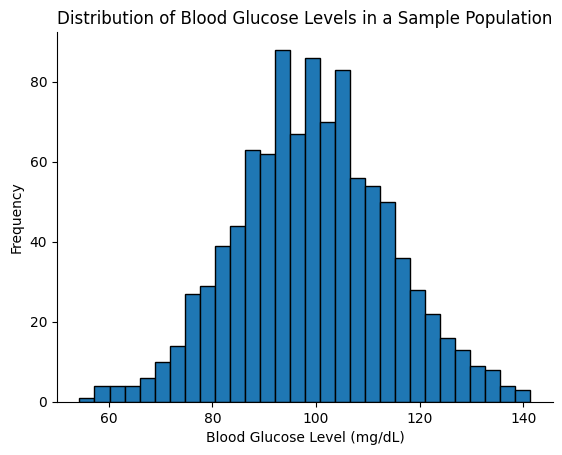

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Generate synthetic data for blood glucose levels in a sample population
np.random.seed(0)
blood_glucose_levels = np.random.normal(loc=100, scale=15, size=1000)

# Create a histogram to show the distribution of blood glucose levels
plt.hist(blood_glucose_levels, bins=30, edgecolor='black')
plt.title('Distribution of Blood Glucose Levels in a Sample Population')
plt.xlabel('Blood Glucose Level (mg/dL)')
plt.ylabel('Frequency')

# remove the top and right spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Show the plot
plt.show()


## Histogram use case #2

Right-skewed distribution. 

This dataset consists of 1097 breast cancer patient cases and is designed for survival analysis using both histopathological and clinical information. The combination of these data sources allows for the exploration of disease progression patterns and the development of predictive models.

source: https://www.kaggle.com/datasets/jmalagontorres/tcga-brca-survival-analysis



In [4]:
import pandas as pd

In [6]:
df_cancer = pd.read_csv('../data/survival_analysis_TCGA-BRCA.csv')

In [7]:
df_cancer.sample(4).T

,947,842,500,489
bcr_patient_barcode,TCGA-EW-A1OW,TCGA-3C-AAAU,TCGA-A2-A3XW,TCGA-JL-A3YW
Time,694.0,4047.0,1712.0,360.0
age_at_initial_pathologic_diagnosis,58,55,42,49
lymph_node_examined_count,3.0,13.0,18.0,16.0
vital_status,1,1,1,1
tissue_prospective_collection_indicator_YES,False,False,True,True
radiation_therapy_NO,False,True,False,True
breast_carcinoma_surgical_procedure_name_Lumpectomy,True,False,False,False
breast_carcinoma_surgical_procedure_name_Other,False,False,False,False
breast_carcinoma_surgical_procedure_name_Simple Mastectomy,False,False,True,False


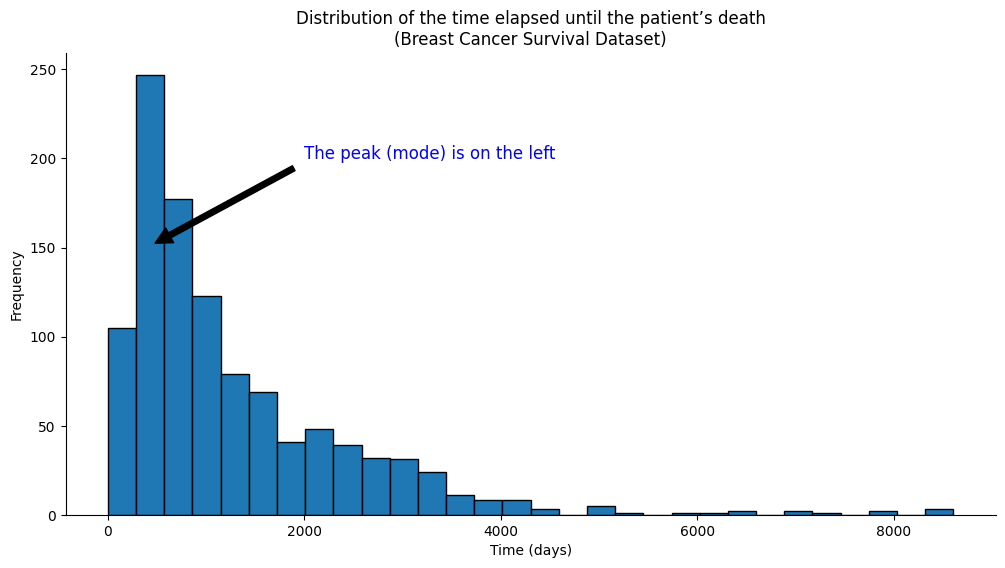

In [8]:
# Plot a histogram of the 'Time' column from the df_cancer dataframe
plt.hist(df_cancer['Time'], bins=30, edgecolor='black')
plt.title('Distribution of the time elapsed until the patient’s death\n(Breast Cancer Survival Dataset)')
plt.xlabel('Time (days)')
plt.ylabel('Frequency')


# annotate the plot with an arrow pointing to the left side of the histogram saying "the peak (mode) is on the left"
plt.annotate('The peak (mode) is on the left',
             xy=(400, 150),  # Adjust the coordinates as needed
             xytext=(2000, 200),
             arrowprops=dict(facecolor='black', shrink=0.05),
             fontsize=12,
             color='blue')

# sets the chart size
plt.gcf().set_size_inches(12, 6)

# remove the top and right spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.show()

TODO:

list out 1 or 2 examples from your own area of expertise where it would make sense to use a histogram

# Boxplots

Boxplots are well suited to show the distribution of data and the presence of outliers.

Box: Represents the interquartile range (IQR) — from the 25th percentile (Q1) to the 75th percentile (Q3).

Line inside the box: The median (50th percentile).

Whiskers: Extend to the smallest and largest values within 1.5 × IQR from the quartiles.

Outliers: Any data points beyond the whiskers are plotted as dots or small circles.

In [9]:
# Load the house prices dataset
df_houe_prices = pd.read_csv('../data/nic-house-prices.csv')

In [10]:
df_houe_prices.columns

Index(['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area',
       'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities',
       'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Overall Qual',
       'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style',
       'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type',
       'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual',
       'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1',
       'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF',
       'Heating', 'Heating QC', 'Central Air', 'Electrical', '1st Flr SF',
       '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath',
       'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr',
       'Kitchen AbvGr', 'Kitchen Qual', 'TotRms AbvGrd', 'Functional',
       'Fireplaces', 'Fireplace Qu', 'Garage Type', 'Garage Yr Blt',
      

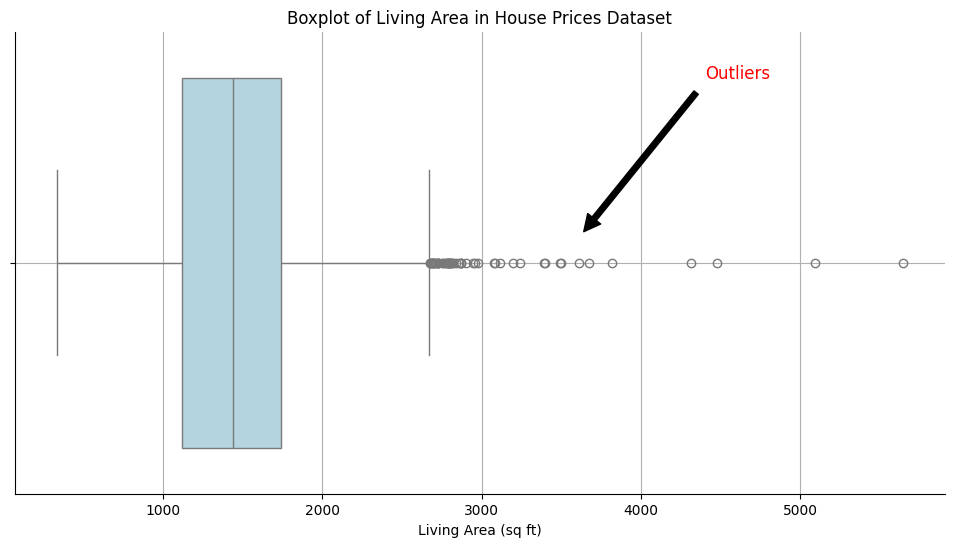

In [11]:
import seaborn as sns

# create a boxplot of the Living Area column
plt.figure(figsize=(12, 6))
sns.boxplot(x=df_houe_prices['Gr Liv Area'], color='lightblue')
plt.title('Boxplot of Living Area in House Prices Dataset')
plt.xlabel('Living Area (sq ft)')
plt.grid(True)
# remove the top and right spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)


# annotate with an arrow pointing to the outliers
plt.annotate('Outliers',
             xy=(3600, -0.05),  # Adjust the coordinates as needed
             xytext=(4400, -0.4),
             arrowprops=dict(facecolor='black', shrink=0.05),
             fontsize=12,
             color='red')

plt.show()

# Swarmplot

A swarm plot also visualizes the distribution of data but it also shows every data point. 

In this code sample, we explore:
- basic swarm plot
- boxplot with swarm plot overlay
- violin plot with swam plot overlay

source: seaborn penguins dataset

Benefit: Unlike box plots or violin plots that summarize the data, a swarm plot displays every single observation. This means no information is lost, and you can see the exact value and position of each data point.

Why it's good: This is particularly useful for smaller to moderately sized datasets where showing individual points is feasible and can reveal nuances hidden by summaries. You can spot outliers, gaps, or clusters within the data very clearly.




In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Load the "penguins" dataset
penguins_df = sns.load_dataset('penguins')

# --- Data Exploration and Preparation ---
print("First 5 rows of the dataset:")
penguins_df.head()


First 5 rows of the dataset:


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


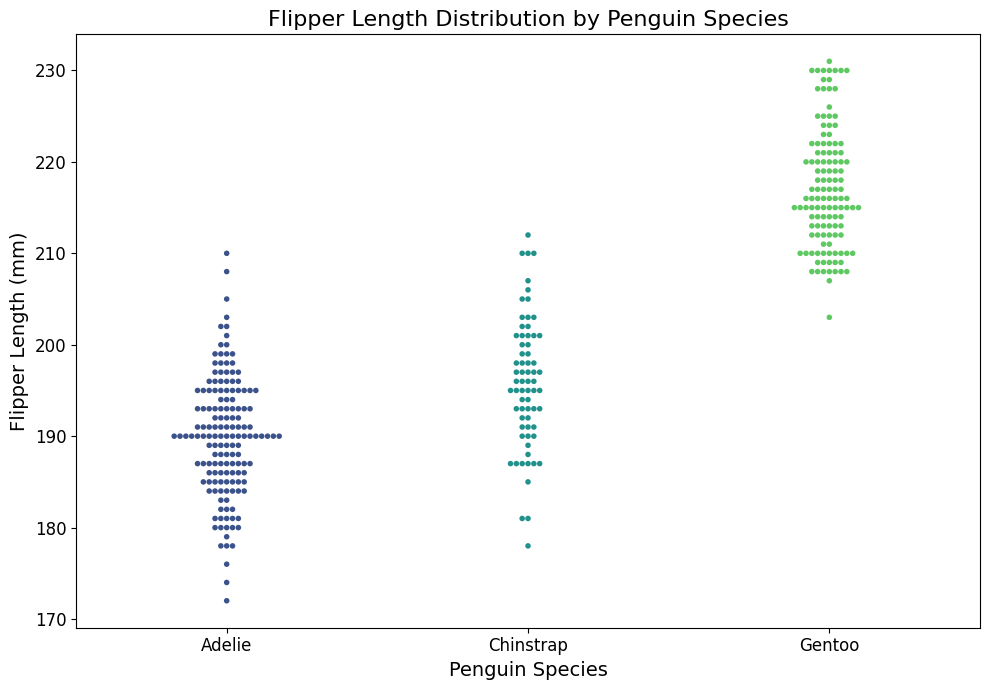

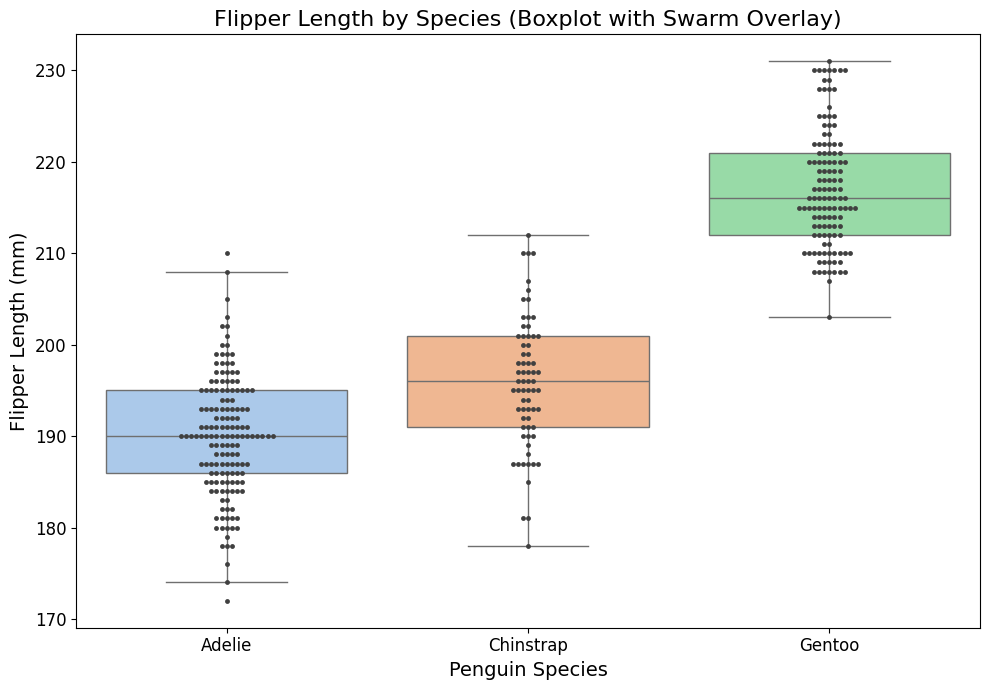

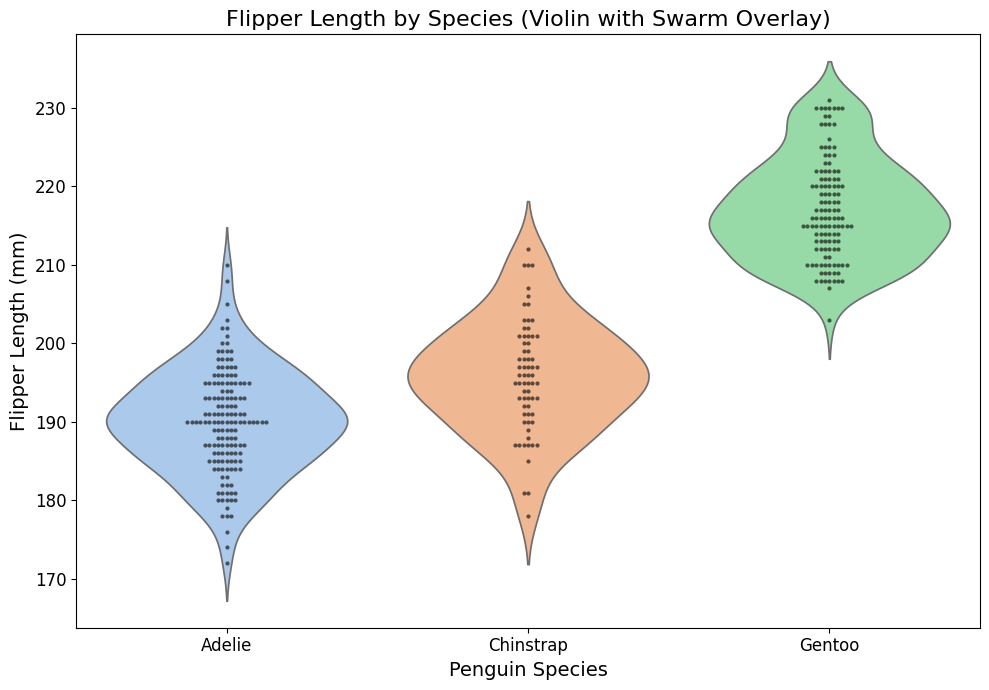

In [14]:


# Drop rows where 'flipper_length_mm' or 'species' is NaN for this specific plot.
penguins_df_cleaned = penguins_df.dropna(subset=['flipper_length_mm', 'species'])

# --- Create the Swarm Plot ---
plt.figure(figsize=(10, 7))

# Create the swarm plot
# x: The categorical variable (penguin species)
# y: The numerical variable (flipper length)
# data: The DataFrame
# hue: The variable to map colors to (same as x in this case)
# palette: Color scheme for different categories
# legend=False: Since hue is the same as x, the x-axis labels act as the legend.
# s: size of the markers
sns.swarmplot(x='species',
              y='flipper_length_mm',
              data=penguins_df_cleaned,
              hue='species',  # Assign x-variable to hue
              palette='viridis',
              s=4,
              legend=False)   # Set legend to False

# Add titles and labels
plt.title('Flipper Length Distribution by Penguin Species', fontsize=16)
plt.xlabel('Penguin Species', fontsize=14)
plt.ylabel('Flipper Length (mm)', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

# --- Alternative: Swarm Plot Overlaid on a Box Plot (Very Common) ---
plt.figure(figsize=(10, 7))

# First, draw the box plot
sns.boxplot(x='species',
            y='flipper_length_mm',
            data=penguins_df_cleaned,
            hue='species',        # Assign x-variable to hue
            palette='pastel',
            showfliers=False,
            legend=False)         # Set legend to False

# Then, overlay the swarm plot
# For this swarmplot, we are using a single 'color', so 'hue' and 'palette' are not needed for coloring.
# If we wanted the swarm points to also be colored by species (and potentially different from boxplot colors),
# we would add hue='species' and a palette here too.
sns.swarmplot(x='species',
              y='flipper_length_mm',
              data=penguins_df_cleaned,
              color=".25", # All points this color, not differentiated by 'species' here
              s=3.5)

plt.title('Flipper Length by Species (Boxplot with Swarm Overlay)', fontsize=16)
plt.xlabel('Penguin Species', fontsize=14)
plt.ylabel('Flipper Length (mm)', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

# --- Alternative: Swarm Plot Overlaid on a Violin Plot ---
plt.figure(figsize=(10, 7))

sns.violinplot(x='species',
               y='flipper_length_mm',
               data=penguins_df_cleaned,
               hue='species',      # Assign x-variable to hue
               palette='pastel',
               inner=None,
               legend=False)       # Set legend to False

# Overlay swarm plot
# Again, using a single 'color' for all swarm points.
sns.swarmplot(x='species',
              y='flipper_length_mm',
              data=penguins_df_cleaned,
              color="k",
              alpha=0.6,
              s=3)

plt.title('Flipper Length by Species (Violin with Swarm Overlay)', fontsize=16)
plt.xlabel('Penguin Species', fontsize=14)
plt.ylabel('Flipper Length (mm)', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

# Heatmap

Color Intensity: Darker cells (towards the blue) indicate months/years with more passengers. Lighter cells (towards yellow) indicate fewer passengers.

Seasonal Pattern: You should clearly see a horizontal pattern. For any given year, the summer months (like June, July, August) will generally be darker (more passengers) than winter months.

Trend Over Years: You should also see a vertical pattern (or a general trend from left to right). As the years progress (from 1949 to 1960), the cells generally become darker, indicating an overall increase in air travel over time.

Specific Values (due to annot=True): You can read the exact number of passengers for any given month and year.

The example is straightforward and clearly demonstrates how a heatmap can visually represent the **magnitude of a phenomenon across two categorical dimensions**.


In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. Load the "flights" dataset
# This dataset is built into Seaborn and is already in a suitable format for a basic heatmap.
flights_long_df = sns.load_dataset("flights")

print("Original 'flights' data:")
flights_long_df.head()


Original 'flights' data:


,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


Pivoted 'flights' data (wide format for heatmap):
year   1949  1950  1951  1952  1953  1954  1955  1956  1957  1958  1959  1960
month                                                                        
Jan     112   115   145   171   196   204   242   284   315   340   360   417
Feb     118   126   150   180   196   188   233   277   301   318   342   391
Mar     132   141   178   193   236   235   267   317   356   362   406   419
Apr     129   135   163   181   235   227   269   313   348   348   396   461
May     121   125   172   183   229   234   270   318   355   363   420   472




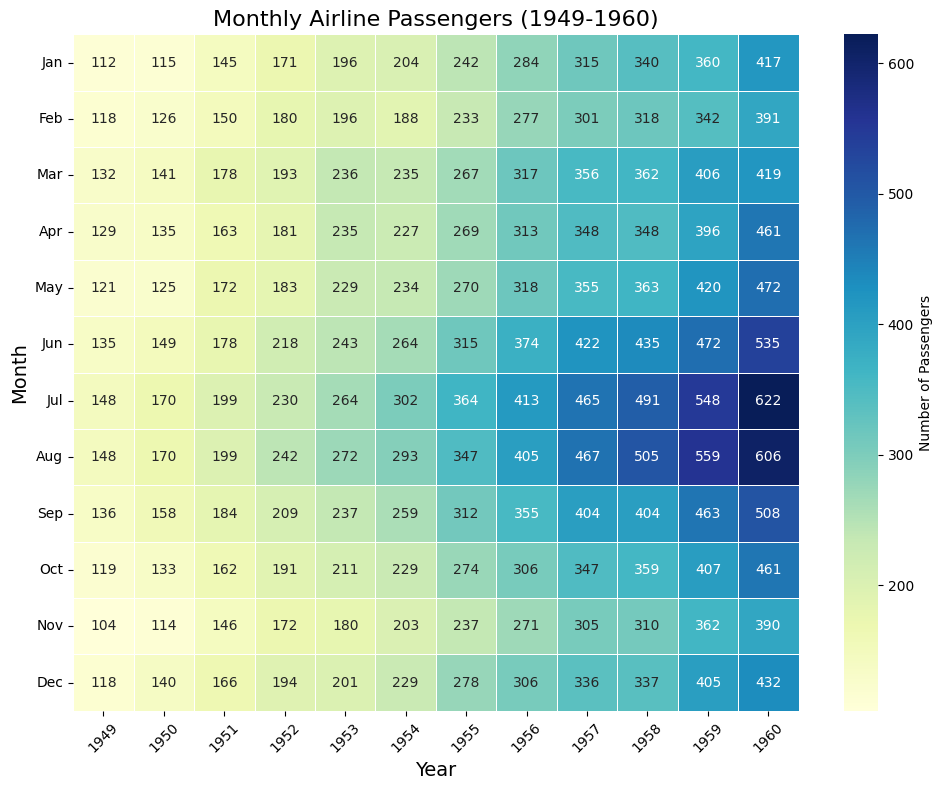

In [16]:

# 2. Pivot the data to a "wide" format suitable for a heatmap
# A heatmap typically expects a 2D matrix where:
# - Rows represent one category (e.g., month)
# - Columns represent another category (e.g., year)
# - The values in the cells are what you want to color-code (e.g., number of passengers)

flights_pivot_df = flights_long_df.pivot(index="month", columns="year", values="passengers")

print("Pivoted 'flights' data (wide format for heatmap):")
print(flights_pivot_df.head())
print("\n")

# 3. Create the Heatmap
plt.figure(figsize=(10, 8)) # Set the figure size for better readability

sns.heatmap(
    flights_pivot_df,      # The pivoted DataFrame
    annot=True,            # Show the actual number of passengers in each cell
    fmt="d",               # Format the annotations as integers (d for decimal integer)
    linewidths=.5,         # Add thin lines between cells for separation
    cmap="YlGnBu",         # Choose a colormap (Yellow-Green-Blue is good for sequential data)
                           # Other good options: "viridis", "magma", "coolwarm" (if data has a meaningful center)
    cbar_kws={'label': 'Number of Passengers'} # Add a label to the color bar
)

# Add titles and labels
plt.title('Monthly Airline Passengers (1949-1960)', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Month', fontsize=14)
plt.xticks(rotation=45) # Rotate x-axis labels for better visibility
plt.yticks(rotation=0)  # Keep y-axis labels horizontal

plt.tight_layout() # Adjust plot to ensure everything fits without overlapping
plt.show()

# Bar charts

Bar charts are good for comparing categories.

In the example below, we use simulated data to show how show female representation by type of jobs

They are ideal for data that falls into separate, non-continuous categories. Each bar represents a unique category.

Example: Types of animals, months of the year, different countries, survey responses (e.g., "Yes," "No," "Maybe").

Bar charts are generally very easy to understand, even for audiences with limited data literacy. The length or height of the bar directly corresponds to its value, making visual comparisons intuitive.

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- 1. Prepare a DataFrame with Simulated Diversity Data ---
# Data represents the percentage of Men and Women in different job categories.
# In a real scenario, you might also include 'Non-binary' or 'Other' categories
# if the data is available and sample sizes are sufficient for meaningful representation.

data = {
    'Job Category': ['Overall Workforce', 'Technical Roles', 'Leadership Roles', 'Non-Technical Roles'],
    'Men (%)': [58, 75, 70, 45],
    'Women (%)': [40, 23, 28, 53],
    'Other/Prefer not to say (%)': [2, 2, 2, 2] # Keeping this simple for the example
}
diversity_df = pd.DataFrame(data)

print("Simulated Company Diversity Data:")
diversity_df



Simulated Company Diversity Data:


,Job Category,Men (%),Women (%),Other/Prefer not to say (%)
0,Overall Workforce,58,40,2
1,Technical Roles,75,23,2
2,Leadership Roles,70,28,2
3,Non-Technical Roles,45,53,2


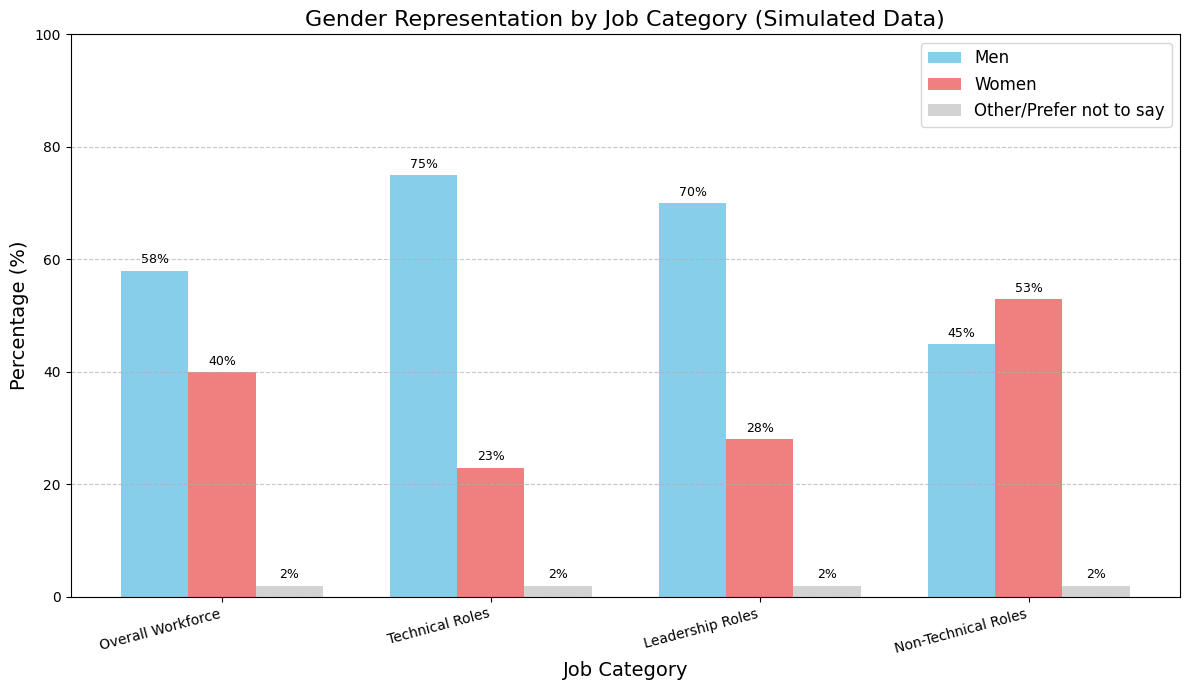

In [19]:

# --- 2. Create a Grouped Bar Chart ---
# We want to compare the percentage of Men and Women side-by-side for each job category.

# Set the positions for the groups on the x-axis
job_categories = diversity_df['Job Category']
x_indexes = np.arange(len(job_categories)) # the label locations: 0, 1, 2, 3

bar_width = 0.25  # Width of each individual bar

# Set up the plot
fig, ax = plt.subplots(figsize=(12, 7))

# Plot bars for 'Men (%)'
rects1 = ax.bar(x_indexes - bar_width, diversity_df['Men (%)'], bar_width, label='Men', color='skyblue')

# Plot bars for 'Women (%)'
rects2 = ax.bar(x_indexes, diversity_df['Women (%)'], bar_width, label='Women', color='lightcoral')

# Plot bars for 'Other/Prefer not to say (%)'
rects3 = ax.bar(x_indexes + bar_width, diversity_df['Other/Prefer not to say (%)'], bar_width, label='Other/Prefer not to say', color='lightgrey')


# Add labels, title, and legend
ax.set_ylabel('Percentage (%)', fontsize=14)
ax.set_xlabel('Job Category', fontsize=14)
ax.set_title('Gender Representation by Job Category (Simulated Data)', fontsize=16)
ax.set_xticks(x_indexes)
ax.set_xticklabels(job_categories, rotation=15, ha="right") # Rotate labels for better fit
ax.legend(fontsize=12)
ax.set_ylim(0, 100) # Percentages go from 0 to 100

# Function to add value labels on top of each bar
def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

plt.grid(axis='y', linestyle='--', alpha=0.7) # Add a light grid for readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()



In [20]:


# --- 3. Alternative: Stacked Bar Chart for Ethnic Diversity (Example) ---
# Let's imagine we have data for ethnic diversity in the 'Overall Workforce'.

ethnic_data = {
    'Category': ['Overall Workforce'], # Could have more categories
    'White': [55],
    'Asian': [25],
    'Hispanic/Latinx': [8],
    'Black/African American': [7],
    'Two or More Races': [3],
    'Other/Not Disclosed': [2]
}


ethnic_df = pd.DataFrame(ethnic_data)
ethnic_df = ethnic_df.set_index('Category') # Set 'Category' as index for easier plotting

print("\nSimulated Ethnic Diversity Data (Overall Workforce):")
ethnic_df



Simulated Ethnic Diversity Data (Overall Workforce):


,White,Asian,Hispanic/Latinx,Black/African American,Two or More Races,Other/Not Disclosed
Category,,,,,,
Overall Workforce,55,25,8,7,3,2


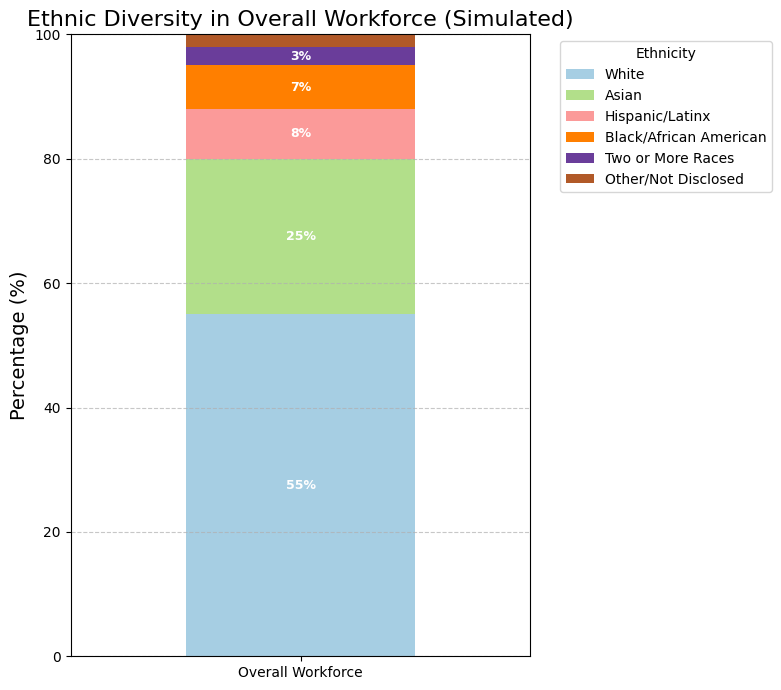

In [21]:


# Create the stacked bar chart
ax_stacked = ethnic_df.plot(
    kind='bar',
    stacked=True,
    figsize=(8, 7),
    colormap='Paired' # A colormap good for categorical data
)

# Add labels and title
ax_stacked.set_ylabel('Percentage (%)', fontsize=14)
ax_stacked.set_xlabel('') # Category is already clear from x-tick
ax_stacked.set_title('Ethnic Diversity in Overall Workforce (Simulated)', fontsize=16)
ax_stacked.legend(title='Ethnicity', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
ax_stacked.set_ylim(0, 100)
plt.xticks(rotation=0)

# Add percentage labels inside the stacked bars (can be a bit more complex)
for c in ax_stacked.containers:
    # Optional: if the segment is small or 0, skip the label
    labels = [f'{v.get_height():.0f}%' if v.get_height() > 2 else '' for v in c]
    ax_stacked.bar_label(c, labels=labels, label_type='center', fontsize=9, color='white', fontweight='bold')


plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Bar charts vs. pie/donut charts?

Humans are Better at Judging Length than Angles, Areas, or Arc Lengths:

Bar charts use length or height to represent values. Our visual system is very adept at accurately comparing lengths along a common baseline.

Pie charts require us to compare angles, areas of slices, or arc lengths. Humans are notoriously poor at making precise judgments of these attributes, especially when slices are not adjacent or are similarly sized.

Research Insight: William S. Cleveland and Robert McGill's foundational work on graphical perception demonstrated a hierarchy of how accurately humans perceive different visual encodings. Position along a common scale (like in a bar chart) is at the top for accuracy, while angle and area (used in pie charts) are much lower down.

When might a pie chart be acceptable?

Showing Part-to-Whole Relationships: When the primary goal is to show how a single whole is divided into a few (2-3, maybe 4) distinct parts, and you want to emphasize their proportion of the total.

Familiar Proportions: If the slices represent well-known fractions like 25%, 50%, or 75%, they can be easier to interpret.

Limited Categories: When you have very few categories.

# Donut chart

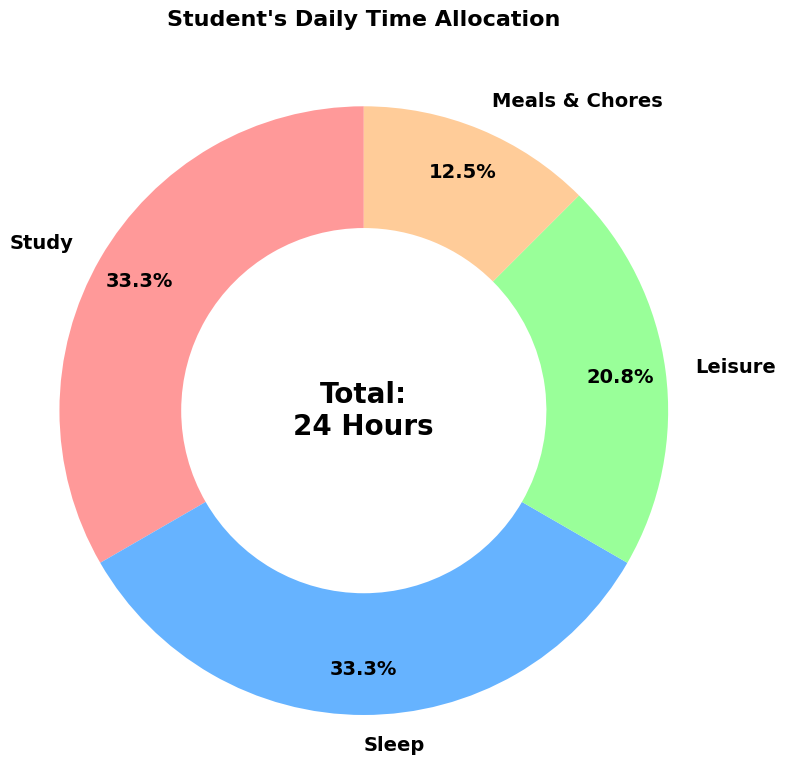

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Prepare the Data ---
# Categories and their corresponding time in hours (for a 24-hour day)
labels = ['Study', 'Sleep', 'Leisure', 'Meals & Chores']
sizes = [8, 8, 5, 3]  # These must sum to 24 for this example, or be normalized to percentages

# Explode a slice (optional, to highlight one category)
# explode = (0, 0.1, 0, 0) # "explode" the 2nd slice (Sleep) slightly

# Colors for each slice (choose colors that are distinct and visually appealing)
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99']
# Or use a predefined colormap:
# cmap = plt.get_cmap("tab20c")
# colors = cmap(np.array([1, 5, 9, 13])) # Pick some colors from the colormap


# --- 2. Create the Donut Chart ---
fig, ax = plt.subplots(figsize=(8, 8)) # Make it a square figure for a circular chart

# Create the pie chart (which will become the donut)
wedges, texts, autotexts = ax.pie(
    sizes,
    # explode=explode, # Uncomment if you want to explode a slice
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',  # Show percentages on slices with 1 decimal place
    startangle=90,      # Start the first slice at the top (90 degrees)
    pctdistance=0.85,   # Distance of the percentage text from the center
    wedgeprops=dict(width=0.4) # This is what makes it a donut!
                               # width=1 would be a full pie. width=0.4 makes the ring.
)

# --- 3. Add a Circle in the Center to make it a Donut ---
# This is an alternative way to achieve the donut effect if wedgeprops isn't used,
# or for more control over the center circle.
# We already used wedgeprops, but this is another common method:
# centre_circle = plt.Circle((0,0),0.70,fc='white')
# fig.gca().add_artist(centre_circle)

# --- 4. Customize the Appearance ---

# Improve label appearance
for text in texts:
    text.set_fontsize(14)
    text.set_fontweight('bold')

for autotext in autotexts:
    autotext.set_color('black') # Color of the percentage text
    autotext.set_fontsize(14)
    autotext.set_fontweight('bold')
    # autotext.set_path_effects([plt.matplotlib.patheffects.withStroke(linewidth=0.5, foreground='white')]) # Optional: add a white stroke for readability

# Add a title
ax.set_title("Student's Daily Time Allocation", fontsize=16, fontweight='bold', pad=20)

# Optional: Add text in the center of the donut
total_hours = sum(sizes)
ax.text(0, 0, f"Total:\n{total_hours} Hours",
        ha='center', va='center', fontsize=20, fontweight='bold')

# Ensure the plot is circular
ax.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.

plt.tight_layout()
plt.show()

# 3D scatter plots

Each dot in the 3D space represents one student.

Its position is determined by their hours studied (x), previous score (y), and final score (z).

The color of the dot also indicates their final score (due to c=final_score).

**note**:

Use sparingly: 3D charts can sometimes be harder to interpret accurately than 2D charts due to issues like occlusion (parts of the chart hiding other parts) and perspective distortion.

Keep it Simple: Don't try to plot too much information on a single 3D chart.


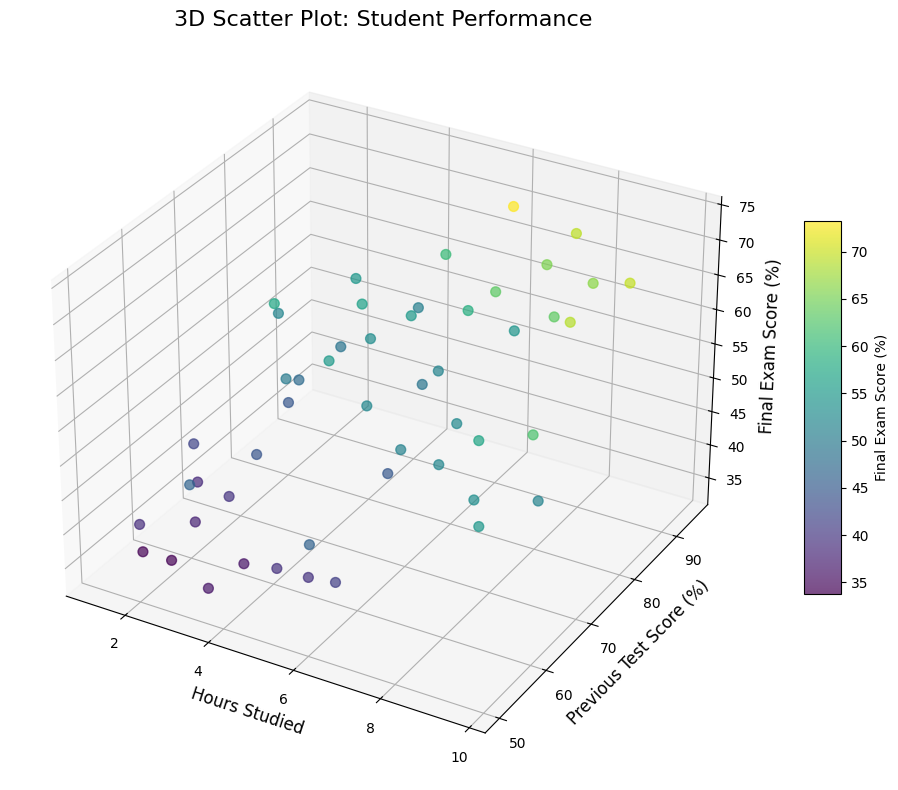

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Generate Some Sample Data ---
np.random.seed(42) # for reproducibility

num_students = 50

# Hours studied (e.g., 1 to 10 hours)
hours_studied = np.random.uniform(1, 10, num_students)

# Previous test score (e.g., 50 to 95)
previous_score = np.random.uniform(50, 95, num_students)

# Final exam score - let's make it somewhat dependent on the other two, plus some noise
# Higher hours studied and higher previous score should generally lead to a higher final score
final_score = (hours_studied * 3) + (previous_score * 0.5) + np.random.normal(0, 5, num_students)
# Ensure scores are within a reasonable range (e.g., 0-100, though this simple model might exceed it)
final_score = np.clip(final_score, 0, 100)

# --- 2. Create the 3D Scatter Plot ---
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d') # Key step for creating a 3D subplot

# Scatter plot
# x: hours_studied
# y: previous_score
# z: final_score
# c: color of the points (can be a single color or an array for different colors per point)
# marker: shape of the points
scatter = ax.scatter(hours_studied, previous_score, final_score,
                     c=final_score,  # Color points by final_score (higher scores = different color)
                     cmap='viridis', # Colormap (e.g., viridis, plasma, coolwarm)
                     s=50,           # Size of the markers
                     marker='o',     # Marker style (o for circle)
                     alpha=0.7)      # Transparency

# --- 3. Add Labels and Title ---
ax.set_xlabel('Hours Studied', fontsize=12)
ax.set_ylabel('Previous Test Score (%)', fontsize=12)
ax.set_zlabel('Final Exam Score (%)', fontsize=12)
ax.set_title('3D Scatter Plot: Student Performance', fontsize=16)

# Add a color bar
cbar = fig.colorbar(scatter, shrink=0.5, aspect=10)
cbar.set_label('Final Exam Score (%)', fontsize=10)

# --- 4. Adjust View (Optional) ---
# You can set the initial viewing angle if desired
# ax.view_init(elev=20., azim=-35) # elev=elevation angle, azim=azimuth angle

plt.tight_layout()
plt.show()

TODO:

choose 2 of the charts presented in this notebook and implement them in your project using your data


# 🌶️ Linear regression (machine learning)

We can re-use the data from the scatter plot which represents the student's performance in relation to the the number of hours spent studying.

The example below shows a basic example of linear regression.

When you run this code, you'll see the same scatter points as before, but with a red dashed line representing the best linear fit through the data, along with a shaded confidence interval around that line. This visually shows the trend that as "Hours Studied" increases, "Test Score" also tends to increase.

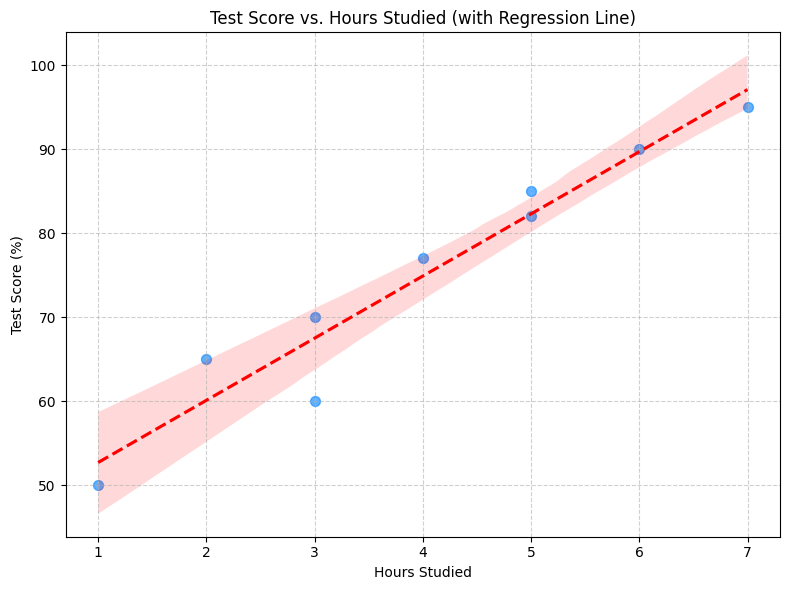

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Seaborn works very well with Pandas DataFrames

# --- 1. Prepare Data (same as before) ---
hours_studied = [2, 3, 5, 1, 6, 4, 7, 3, 5]
test_scores   = [65, 70, 85, 50, 90, 77, 95, 60, 82]

# --- 2. Create a Pandas DataFrame ---
# Seaborn functions typically expect data in a DataFrame.
data = {'Hours Studied': hours_studied, 'Test Score': test_scores}
df = pd.DataFrame(data)

# --- 3. Create the Scatter Plot with Regression Line using Seaborn ---
plt.figure(figsize=(8, 6)) # Optional: Set the figure size

# Use sns.regplot()
# x: column name for x-axis
# y: column name for y-axis
# data: the DataFrame
sns.regplot(x='Hours Studied', y='Test Score', data=df,
            scatter_kws={'s': 50, 'alpha':0.7, 'color':'dodgerblue'}, # Customize scatter points
            line_kws={'color':'red', 'linestyle':'--'})             # Customize regression line

# --- 4. Add Labels and Title ---
plt.title('Test Score vs. Hours Studied (with Regression Line)')
plt.xlabel('Hours Studied')
plt.ylabel('Test Score (%)')

# --- 5. Optional: Add a Grid ---
plt.grid(True, linestyle='--', alpha=0.6)

# --- 6. Show the Plot ---
plt.tight_layout() # Adjust layout to make sure everything fits
plt.show()

# 🌶️ Geopandas

you need to install geopandas to run the example below.

to install the library you can remove the comment from the cell below

In [25]:
#!pip install geopandas
#!pip install shapely
!pip install geodatasets



   ---------------------------------------- 0/2 [pooch]
   -------------------- ------------------- 1/2 [geodatasets]
   ---------------------------------------- 2/2 [geodatasets]




[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


GeoPandas version: 1.1.1
Attempting to load 'naturalearth.land' using 'geodatasets' library...
Successfully loaded 'naturalearth.land'.

Land Basemap CRS: EPSG:4326
Cities GeoDataFrame CRS: EPSG:4326
Airports GeoDataFrame CRS: EPSG:4326


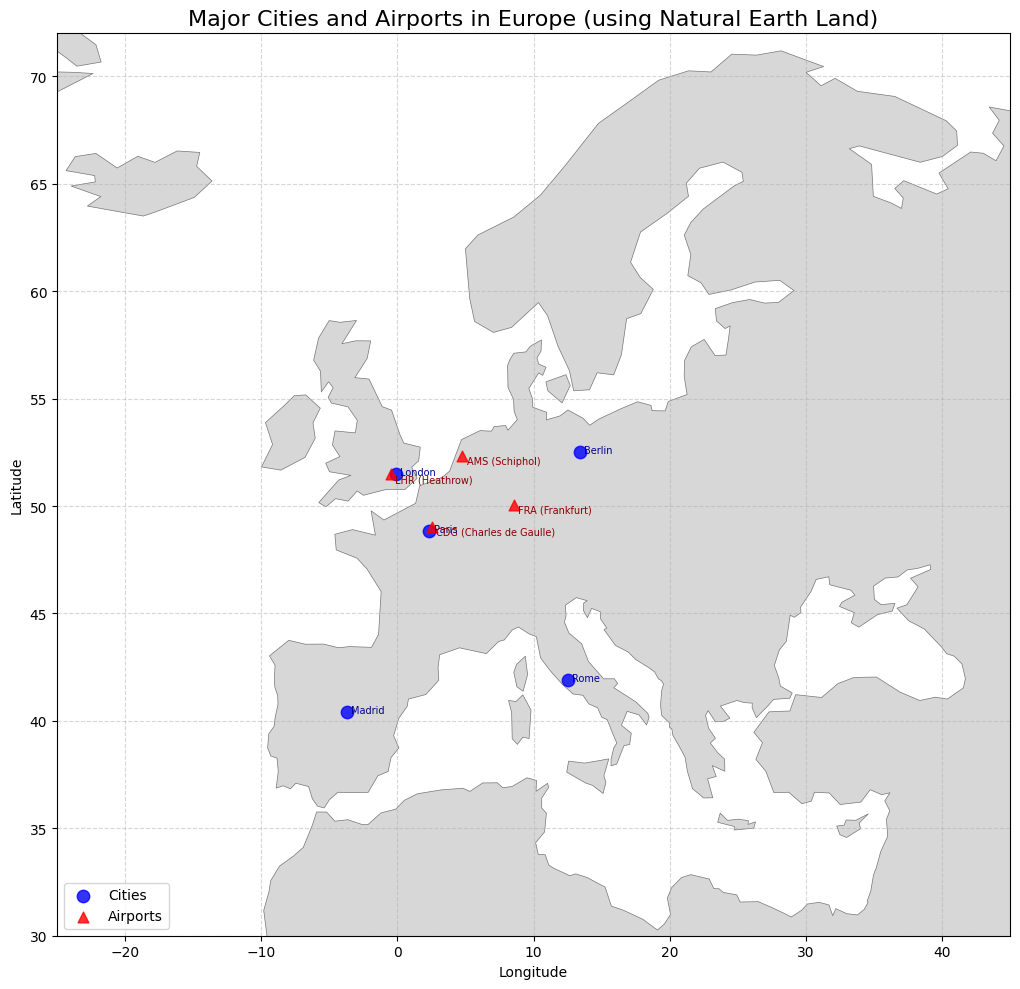

In [26]:
import geopandas
import matplotlib.pyplot as plt
from shapely.geometry import Point
import geodatasets # For accessing a wider range of datasets

print(f"GeoPandas version: {geopandas.__version__}")

# --- 1. Load a Different Basemap (e.g., Natural Earth Land Polygons) ---
land_gdf = None
try:
    print("Attempting to load 'naturalearth.land' using 'geodatasets' library...")
    # This dataset provides global land polygons, without country-specific attributes like 'continent'.
    land_filepath = geodatasets.get_path('naturalearth.land')
    land_gdf = geopandas.read_file(land_filepath)
    print("Successfully loaded 'naturalearth.land'.")
except ImportError:
    print("Error: 'geodatasets' library not installed. Please install it: pip install geodatasets")
    exit()
except Exception as e: # Catch other potential errors from geodatasets or read_file
    print(f"Error loading 'naturalearth.land': {e}")
    exit()

if land_gdf is None: # Should not happen if previous try-except worked, but as a safeguard
    print("\nCRITICAL ERROR: Could not load the land basemap. Exiting.")
    exit()

print(f"\nLand Basemap CRS: {land_gdf.crs}") # Likely EPSG:4326

# --- 2. Define and Create GeoDataFrame for Major European Cities ---
# This part remains the same as the previous example.
cities_data = [
    {'name': 'Paris', 'latitude': 48.8566, 'longitude': 2.3522},
    {'name': 'Berlin', 'latitude': 52.5200, 'longitude': 13.4050},
    {'name': 'Rome', 'latitude': 41.9028, 'longitude': 12.4964},
    {'name': 'Madrid', 'latitude': 40.4168, 'longitude': -3.7038},
    {'name': 'London', 'latitude': 51.5074, 'longitude': -0.1278},
]
city_geometry = [Point(city['longitude'], city['latitude']) for city in cities_data]
cities_gdf = geopandas.GeoDataFrame(cities_data, geometry=city_geometry, crs="EPSG:4326")
print(f"Cities GeoDataFrame CRS: {cities_gdf.crs}")

# --- 3. Define and Create GeoDataFrame for Major European Airports ---
# This part also remains the same.
airports_data = [
    {'name': 'LHR (Heathrow)', 'city': 'London', 'latitude': 51.4700, 'longitude': -0.4543},
    {'name': 'CDG (Charles de Gaulle)', 'city': 'Paris', 'latitude': 49.0097, 'longitude': 2.5479},
    {'name': 'FRA (Frankfurt)', 'city': 'Frankfurt', 'latitude': 50.0379, 'longitude': 8.5622},
    {'name': 'AMS (Schiphol)', 'city': 'Amsterdam','latitude': 52.3105, 'longitude': 4.7683},
]
airport_geometry = [Point(ap['longitude'], ap['latitude']) for ap in airports_data]
airports_gdf = geopandas.GeoDataFrame(airports_data, geometry=airport_geometry, crs="EPSG:4326")
print(f"Airports GeoDataFrame CRS: {airports_gdf.crs}")

# --- 4. Ensure All Layers Have the Same CRS ---
# 'naturalearth.land' is typically in EPSG:4326, so it should match our points.
# The check and reprojection logic remains important.
if not (land_gdf.crs == cities_gdf.crs == airports_gdf.crs):
    print("\nWarning: CRS mismatch detected. Reprojecting points to match basemap CRS.")
    target_crs = land_gdf.crs
    cities_gdf = cities_gdf.to_crs(target_crs)
    airports_gdf = airports_gdf.to_crs(target_crs)
    print(f"All layers now in CRS: {target_crs}")

# --- 5. Plot the Map ---
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Plot land polygons (this will be the entire world's landmass)
land_gdf.plot(
    ax=ax,
    color='lightgray',
    edgecolor='dimgray', # Slightly darker edge for land
    linewidth=0.5,
    alpha=0.9
)

# Plot cities
cities_gdf.plot(
    ax=ax,
    marker='o',
    color='blue',
    markersize=80,
    label='Cities',
    alpha=0.8,
    zorder=3 # Ensure cities are plotted on top of land
)

# Plot airports
airports_gdf.plot(
    ax=ax,
    marker='^',
    color='red',
    markersize=60,
    label='Airports',
    alpha=0.8,
    zorder=4 # Ensure airports are on top of cities (or adjust zorder as needed)
)

# Optional: Add labels (can get cluttered, use sparingly or with offsets)
for gdf, label_color, offset_y_factor in [(cities_gdf, 'darkblue', 0.2), (airports_gdf, 'darkred', -0.25)]:
    for x, y, label in zip(gdf.geometry.x, gdf.geometry.y, gdf['name']):
        ax.annotate(
            label,
            xy=(x, y),
            xytext=(3, -3 + offset_y_factor * 10), # Adjust offset as needed
            textcoords="offset points",
            fontsize=7,
            color=label_color,
            zorder=5 # Ensure labels are on top
        )

# --- 6. Customize and Show Plot ---
ax.set_title('Major Cities and Airports in Europe (using Natural Earth Land)', fontsize=16)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

# CRITICAL: Set map limits to focus on Europe because 'naturalearth.land' is global
# These are approximate longitude/latitude bounds for Europe. Adjust as needed.
ax.set_xlim([-25, 45])
ax.set_ylim([30, 72])

ax.legend(loc='lower left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Note: there is another example of using geopandas in the demo folder: 

zurisee_geopandas.ipynb

# 🌶️ Interactive visualization 

This example demonstrates a fundamental pattern for creating interactive visualizations with ipywidgets and Matplotlib. 

You can adapt this to control various aspects of your plots, like colors, line styles, data ranges, etc., using different types of widgets.

In [27]:
!pip install ipywidgets

   ---------------------------------------- 0.0/914.9 kB ? eta -:--:--
   ---------------------------------- ----- 786.4/914.9 kB 4.1 MB/s eta 0:00:01
   ---------------------------------------- 914.9/914.9 kB 3.5 MB/s  0:00:00
   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.2 MB ? eta -:--:--
   ------------------- -------------------- 1.0/2.2 MB 2.4 MB/s eta 0:00:01
   --------------------------------- ------ 1.8/2.2 MB 3.0 MB/s eta 0:00:01
   ---------------------------------------- 2.2/2.2 MB 3.0 MB/s  0:00:00

   ------------- -------------------------- 1/3 [jupyterlab_widgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   ---------------------------------------- 3/3 [ipywidgets]




[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Prepare Sample Data for Plotting ---
x = np.linspace(0, 2 * np.pi, 100) # Common x-axis for all lines
data_series = {
    'Sine Wave (Original)': np.sin(x),
    'Cosine Wave': np.cos(x),
    'Sine Wave (2x Frequency)': np.sin(2 * x),
    'Sine Wave (Half Amplitude)': 0.5 * np.sin(x)
}
colors = {
    'Sine Wave (Original)': 'blue',
    'Cosine Wave': 'red',
    'Sine Wave (2x Frequency)': 'green',
    'Sine Wave (Half Amplitude)': 'purple'
}

# --- 2. Create the Widgets ---

# Output widget to display the Matplotlib plot
plot_output = widgets.Output()

# Create a checkbox for each data series
# We'll store them in a dictionary for easy access
checkboxes = {}
for series_name in data_series.keys():
    checkboxes[series_name] = widgets.Checkbox(
        value=True,  # Initially checked (visible)
        description=series_name,
        disabled=False,
        indent=False
    )

# --- 3. Define the Plotting Function ---
# This function will be called whenever a checkbox value changes.
def update_plot(change): # The 'change' argument is passed by the .observe() method
    with plot_output:
        clear_output(wait=True) # Clear the previous plot before drawing a new one
        
        fig, ax = plt.subplots(figsize=(10, 6)) # Create a new figure and axes each time
        
        active_series_count = 0
        for series_name, checkbox_widget in checkboxes.items():
            if checkbox_widget.value: # If the checkbox is checked
                ax.plot(x, data_series[series_name], label=series_name, color=colors[series_name])
                active_series_count += 1
        
        ax.set_title('Interactive Plot Controlled by Checkboxes')
        ax.set_xlabel('X-axis (Radians)')
        ax.set_ylabel('Y-axis (Value)')
        ax.grid(True, linestyle='--', alpha=0.7)
        
        if active_series_count > 0: # Only show legend if there are lines plotted
            ax.legend(loc='upper right')
        else:
            ax.text(0.5, 0.5, 'No series selected to display',
                    horizontalalignment='center', verticalalignment='center',
                    transform=ax.transAxes, fontsize=12, color='gray')

        plt.show() # Display the plot in the output widget

# --- 4. Link Checkboxes to the Update Function ---
# We use the .observe() method. Whenever the 'value' of a checkbox changes,
# the update_plot function will be called.
for checkbox_widget in checkboxes.values():
    checkbox_widget.observe(update_plot, names='value')

# --- 5. Arrange and Display Widgets ---
# Create a VBox to hold all the checkboxes
checkbox_container = widgets.VBox(list(checkboxes.values()))

# Display the checkboxes and the plot output area side-by-side or one above the other
# HBox for side-by-side
ui = widgets.HBox([checkbox_container, plot_output])
# VBox for one above the other
# ui = widgets.VBox([checkbox_container, plot_output])

print("Select series to display:")
display(ui)

# --- 6. Initial Plot Draw ---
# Call update_plot once manually to draw the initial plot based on default checkbox states
update_plot(None) # Pass None or a dummy change object

Select series to display:


# 🌶️ Pair plots

A pair plot (also known as a scatter plot matrix) is a grid (or matrix) of plots where each plot shows the relationship between a pair of variables in a dataset.

What to look for in pair plots:

- Correlations: Do points tend to form a line (positive or negative correlation)?
- Clusters: Do different species form distinct groups in these 2D spaces? For instance, petal length vs. petal width typically shows very good separation between the species.
- Outliers: Any points that are far away from the main clusters.

In the example below we look at the Anderson's Iris data set (available from seaborn).

Specifically, we look at the pair plots for these 4 variables:

- sepal_length
- sepal_width
- petal_length	
- petal_width	

and use different markers to represent the 3 iris' species:
- setosa        
- versicolor    
- virginica  

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd # Good practice, though load_dataset returns a DataFrame

# --- 1. Load the "iris" Dataset ---
# This dataset is built into Seaborn.
# It contains measurements for 3 species of iris flowers.
iris_df = sns.load_dataset('iris')

# --- 2. Initial Exploration (Optional but good practice) ---
print("First 5 rows of the Iris dataset:")
iris_df.head()


In [ ]:
iris_df.species.value_counts()

In [ ]:


# --- 3. Create the Pair Plot ---
# We'll use Seaborn's pairplot function.

# Set a style for better aesthetics (optional)
sns.set_theme(style="ticks") # "ticks", "whitegrid", "darkgrid", "white", "dark"

plt.figure(figsize=(10, 8)) # Set overall figure size (pairplot creates its own figure, but this can influence context)

# Create the pair plot
# hue='species': Colors the points and KDEs/histograms by the 'species' column.
# diag_kind='kde': Shows Kernel Density Estimates on the diagonal. 'hist' for histograms.
# palette: Chooses a color scheme for the species.
# markers: Uses different markers for different species in scatter plots.
pair_plot_fig = sns.pairplot(
    iris_df,
    hue='species',
    diag_kind='kde',  # Options: 'kde', 'hist'
    palette='viridis', # Examples: 'viridis', 'plasma', 'husl', 'Set2'
    markers=["o", "s", "D"], # Circle, Square, Diamond for the 3 species
    plot_kws={'alpha': 0.7, 's': 60, 'edgecolor': 'k'}, # Keyword args for scatter plots
    diag_kws={'fill': True, 'alpha': 0.6} # Keyword args for diagonal plots (KDEs)
)

# Add a more descriptive overall title (suptitle for the Figure object)
pair_plot_fig.fig.suptitle('Pair Plot of Iris Dataset Features by Species', y=1.02, fontsize=16) # Adjust y to position title

# Adjust layout to prevent title overlap (sometimes needed)
# plt.tight_layout() # Often handled well by pairplot itself

# --- 4. Show the Plot ---
plt.show()

# --- More Basic Pair Plot (fewer customizations) ---
# If you want a simpler version to start with:
# plt.figure() # Reset figure context if needed
# sns.pairplot(iris_df, hue='species')
# plt.suptitle('Basic Pair Plot of Iris Dataset', y=1.02)
# plt.show()

# Summary

1. Histogram:
Purpose: To understand the distribution of a single numerical variable. It shows the frequency of data points falling into specified bins or ranges.
Use Case: Checking if a feature is normally distributed, skewed, bimodal; identifying outliers or gaps in data.

2. Bar Chart (or Count Plot):
Purpose: To compare the frequency or magnitude of different categories for a categorical variable, or to show discrete numerical values for different categories.
Use Case: Showing the number of customers in different segments, sales per product category, frequency of different error types.

3. Scatter Plot:
Purpose: To visualize the relationship between two numerical variables. Each point represents an observation.
Use Case: Identifying correlation (positive, negative, none), clusters, outliers, and the general pattern of interaction between two features (e.g., height vs. weight, advertising spend vs. sales). Often enhanced with a hue parameter to show a third categorical variable.

4. Line Chart (or Line Plot):
Purpose: To display trends over a continuous interval or time series. Points are connected by lines, showing progression.
Use Case: Tracking stock prices over time, website traffic per day, temperature changes, model performance over training epochs.

5. Box Plot (Box and Whisker Plot):
Purpose: To summarize the distribution of a numerical variable, often compared across different categories. It shows the median, quartiles (IQR), and potential outliers.
Use Case: Comparing salary distributions across different job roles, an A/B test result for different groups, sensor readings from different devices.

6. Heatmap:
Purpose: To visualize the magnitude of a phenomenon as color in two dimensions (a matrix).
Use Case: Showing correlation matrices between features, user activity on a website grid, gene expression levels across samples, confusion matrices for classification models.

7. Pair Plot (Scatter Plot Matrix):
Purpose: To visualize pairwise relationships between multiple numerical variables in a dataset simultaneously. The diagonal often shows univariate distributions (histograms or KDEs) of each variable.
Use Case: Quick exploratory data analysis (EDA) to get an overview of correlations and distributions for several features at once, especially when using a hue for a categorical variable.

8. Pie Chart (Use with Caution):
Purpose: To show proportions or parts of a whole for a categorical variable.
Use Case: Displaying market share, budget allocation. However, data visualization experts often recommend bar charts over pie charts because humans are better at comparing lengths than angles/areas, especially with many slices. Best used for a very small number of categories (2-4).

9. Violin Plot:
Purpose: Combines aspects of a box plot and a density plot. It shows the distribution shape (KDE) along with summary statistics (often an inner box plot or quartile lines).
Use Case: Comparing the distribution shapes of a numerical variable across different categories, especially when you want to see modality (e.g., if a distribution is bimodal).


The choice of visualization always depends on:
- The type of data you have (numerical, categorical, time series, geospatial).
- The question you are trying to answer or the story you are trying to tell.
- Your audience.